In [3]:
from graph_transformer_long_range_niches.tl.wandb import load_and_log
from graph_transformer_long_range_niches.tl.load_config import Config
from graph_transformer_long_range_niches._paths import CFG_FILES
from graph_transformer_long_range_niches.model.gnn_transformer import LitGNNTransformer
from graph_transformer_long_range_niches.tl.utils import pad_batch

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Log and load data 

In [20]:
cfg_path = Path(CFG_FILES, 'He23/he23_gnntrans_niche.yaml')
cfg = Config(cfg_path)

Load cfg file...
{'out_dir': 'results', 'wandb': {'use': True, 'project_name': 'GTLongRange', 'run_idx': None}, 'model': {'model_type': 'gnn-transformer', 'n_epochs': 100}, 'optim': {'lr': 0.001, 'wd': '1e-3', 'warm_up': 10, 'seed': 42}, 'dataset': {'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/unprocessed_data/he22_cosmx_human_lung.h5ad', 'name': 'he23_niche_window', 'description': "CosmX Lung data from He23 with graphs for each .obs['window'] and prediction node .obs['niche'].", 'prediction_task': 'node', 'prediction_obs': 'niche', 'library_key': 'window', 'subset_dict': {}, 'spatial_neigbors_kwargs': {'radius': 30, 'coord_type': 'generic'}, 'batch_size': 20, 'train_size': 0.8, 'val_size': 0.2, 'test_size': 0.0}, 'gnn': {'gnn_type': 'GCN', 'num_layers': 2, 'hidden_dim': 256, 'embed_dim': 256, 'dropout': 0.1}, 'transformer': {'d_model': 128, 'n_heads': 4, 'dim_feedforward': 512, 'dropout': 0.3, 'num_layers': 4, 'activation_func': 'relu', 'num_

In [3]:
load_and_log(cfg)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: francesca-drummer. Use `wandb login --relogin` to force relogin


Load PyG data...
No subset creation.
[Data(x=[1169, 960], edge_index=[2, 42], y=[1169, 9]), Data(x=[2573, 960], edge_index=[2, 244], y=[2573, 9]), Data(x=[2527, 960], edge_index=[2, 206], y=[2527, 9])]
375
train ds: 300, val ds: 75


/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/torch_geometric/data/lightning/datamodule.py:43: The 'shuffle=True' option is ignored in 'LightningDataset'. Remove it from the argument list to disable this warning


Load data from WandB

In [6]:
with wandb.init(project=cfg.get('wandb/project_name'), job_type="load-data", name = 'data_'+cfg.get('dataset/name')) as run:
    name = cfg.get('dataset/name')
    data_artifact = run.use_artifact(f'{name}:latest')

Thread HandlerThread:
Traceback (most recent call last):
  File "/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/wandb/sdk/internal/internal_util.py", line 49, in run
    self._run()
  File "/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/wandb/sdk/internal/internal_util.py", line 100, in _run
    self._process(record)
  File "/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/wandb/sdk/internal/internal.py", line 279, in _process
    self._hm.handle(record)
  File "/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/wandb/sdk/internal/handler.py", line 138, in handle
    handler(record)
  File "/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/wandb/sdk/internal/handler.py", line 148, in handle_request
    handler(record)
  File "/home/icb/francesca.drummer/tools

Problem at: /home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/wandb/sdk/wandb_init.py 849 getcaller



KeyboardInterrupt



In [13]:
data = data_artifact.download()

wandb: Downloading large artifact he23_niche_window:latest, 2852.93MB. 2 files... 
wandb:   2 of 2 files downloaded.  
Done. 0:1:12.2


In [4]:
def read(data_dir, split):
    filename = split + ".pt"
    pyg_data = torch.load(os.path.join(data_dir, filename))
    return pyg_data # list with PyG Data objects

In [ ]:
data_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts/he23_niche_window:v0'

In [14]:
pyg_data_val = read(data_dir, 'validation')

# Download model

In [3]:
name = cfg.get('dataset/name') + '_' + cfg.get('model/model_type')
name

'he23_niche_window_gnn-transformer'

In [8]:
# name = cfg.get('dataset/name') + cfg.get('model/model_type')
# with wandb.init(project=cfg.get('wandb/project_name'), 
#                 job_type="load_model", 
#                 #name = cfg.get('dataset/name') + cfg.get('model/model_type')) as run:
#                 name = 'load_model_' + name) as run:
#     artifact = run.use_artifact('model-srw7c0r8:best', type='model')
#     artifact_dir = artifact.download()
#     model_path = f'{artifact_dir}/model.pth'
#     model = torch.load(model_path)

In [5]:
import wandb
run = wandb.init()
artifact = run.use_artifact('francesca-drummer/GTLongRange/model-srw7c0r8:v99', type='model')
artifact_dir = artifact.download()

wandb:   1 of 1 files downloaded.  


# Run evaluation

How does Ale retrieve the attention map? [https://github.com/theislab/spatial-transformer/blob/c882e5a1a43b07a17ba8ea32fc59344cd01047cf/src/spatra/model/_transformer.py#L363](https://github.com/theislab/spatial-transformer/blob/c882e5a1a43b07a17ba8ea32fc59344cd01047cf/src/spatra/model/_transformer.py#L363)

Extract self-attention maps from nn.TransformerEncoder: [https://discuss.pytorch.org/t/extracting-self-attention-maps-from-nn-transformerencoder/139998](https://discuss.pytorch.org/t/extracting-self-attention-maps-from-nn-transformerencoder/139998)

In [5]:
artifact_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts/model-srw7c0r8:v99'
data_dir = '/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/docs/notebooks/artifacts/he23_niche_window:v0'

In [6]:
model_path = f'{artifact_dir}/model.ckpt'
checkpoint = torch.load(model_path)

In [7]:
cfg = checkpoint['hyper_parameters']['cfg']

In [8]:
model = LitGNNTransformer(cfg)

/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [9]:
model.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>

In [10]:
pyg_data_val = read(data_dir, 'validation')

In [68]:
def eval(self, batched_data):
    h_node, z = self.gnn(batched_data.x, batched_data.edge_index)
    h_node = self.gnn2transformer(h_node) 
    padded_h_node, src_padding_mask, index_nodes, num_nodes, mask, max_num_nodes = pad_batch(
            h_node, batched_data.batch, self.transformer_encoder.max_input_len, get_mask=True
        )
    transformer_in = padded_h_node
    return transformer_in, src_padding_mask, index_nodes


In [60]:
# self = model
def extract_attention(self, x, src_padding_mask):
    """Returns a list of attention maps (Tensor) for each Transformer layer.
    """
    attention_maps = []
        
    num_layers = self.transformer_encoder.num_layers
    num_heads = self.transformer_encoder.layers[0].self_attn.num_heads
    norm_first = self.transformer_encoder.layers[0].norm_first

    with torch.no_grad():
        for i in range(num_layers):
            # compute attention of layer i
            h = x.clone()
            if norm_first:
                h = self.transformer_encoder.layers[i].norm1(h)
            attn = self.transformer_encoder.layers[i].self_attn(h, h, h, need_weights=True, key_padding_mask=src_padding_mask)[1]
            attention_maps.append(attn)
            # forward of layer i
            x = self.transformer_encoder.layers[i](x)
            
        # attention_maps = torch.stack(attention_maps, dim=0)
        # attention_maps = torch.mean(attention_maps, dim=0)
        
    return attention_maps

In [55]:
data_batch = pyg_data_val
data_batch

[Data(x=[1775, 960], edge_index=[2, 32], y=[1775, 9]),
 Data(x=[3517, 960], edge_index=[2, 1906], y=[3517, 9]),
 Data(x=[457, 960], edge_index=[2, 38], y=[457, 9]),
 Data(x=[2410, 960], edge_index=[2, 136], y=[2410, 9]),
 Data(x=[3043, 960], edge_index=[2, 1318], y=[3043, 9]),
 Data(x=[2273, 960], edge_index=[2, 132], y=[2273, 9]),
 Data(x=[1809, 960], edge_index=[2, 156], y=[1809, 9]),
 Data(x=[1788, 960], edge_index=[2, 56], y=[1788, 9]),
 Data(x=[3613, 960], edge_index=[2, 1734], y=[3613, 9]),
 Data(x=[3189, 960], edge_index=[2, 346], y=[3189, 9]),
 Data(x=[1307, 960], edge_index=[2, 38], y=[1307, 9]),
 Data(x=[2020, 960], edge_index=[2, 166], y=[2020, 9]),
 Data(x=[2493, 960], edge_index=[2, 178], y=[2493, 9]),
 Data(x=[3180, 960], edge_index=[2, 1558], y=[3180, 9]),
 Data(x=[2403, 960], edge_index=[2, 192], y=[2403, 9]),
 Data(x=[2490, 960], edge_index=[2, 198], y=[2490, 9]),
 Data(x=[1169, 960], edge_index=[2, 42], y=[1169, 9]),
 Data(x=[322, 960], edge_index=[2, 8], y=[322, 9]),

In [56]:
from torch_geometric.loader import DataLoader
eval_loader = DataLoader(data_batch[:3], 1)
eval_loader

In [15]:
for batch in eval_loader:
    print(batch)
    transformer_in, src_padding_mask = eval(model, batch)
    attention_maps = extract_attention(model.transformer_encoder, transformer_in, src_padding_mask)

DataBatch(x=[1775, 960], edge_index=[2, 32], y=[1775, 9], batch=[1775], ptr=[2])
DataBatch(x=[3517, 960], edge_index=[2, 1906], y=[3517, 9], batch=[3517], ptr=[2])
DataBatch(x=[457, 960], edge_index=[2, 38], y=[457, 9], batch=[457], ptr=[2])


In [16]:
for att_map in attention_maps:
    print(att_map.shape)

torch.Size([1, 457, 457])
torch.Size([1, 457, 457])
torch.Size([1, 457, 457])
torch.Size([1, 457, 457])


### Attention matrix with cells pooled by category

In [69]:
from torch_geometric.data import Data
import numpy as np

def create_label_heatmap(data: Data, attention_matrix: torch.Tensor, index_nodes):
    """
    Creates a heatmap for nodes with the same label pooled together based on the attention matrix.
    
    Parameters:
    - data (Data): PyG data object containing node features `x` and labels `y`.
    - attention_matrix (torch.Tensor): Attention matrix of size NxN.
    
    Returns:
    - None: Displays a heatmap.
    """
    # Ensure attention_matrix is square and matches the number of nodes
    if not attention_matrix.shape[0] == attention_matrix.shape[1] == data.x.shape[0]:
        labels = np.argmax(data.y[index_nodes], axis = 1)
    else:
        labels = np.argmax(data.y, axis = 1)
        
    nr_labels = len(data.y[1])
    
    # Create an empty matrix to store aggregated attention scores
    label_attention_matrix = torch.zeros((nr_labels, nr_labels))

    # Aggregate attention scores for nodes with the same label
    for i, label_i in enumerate(range(nr_labels)):
        for j, label_j in enumerate(range(nr_labels)):
            # Get the indices of nodes with label_i and label_j
            indices_i = (labels == label_i).nonzero(as_tuple=True)[0]
            indices_j = (labels == label_j).nonzero(as_tuple=True)[0]
            
            # Sum the attention scores between nodes of label_i and label_j
            attention_sum = attention_matrix[indices_i][:, indices_j].sum().item()
            label_attention_matrix[i, j] = attention_sum
            #TODO: Average
    
    return label_attention_matrix.numpy()


DataBatch(x=[1775, 960], edge_index=[2, 32], y=[1775, 9], batch=[1775], ptr=[2])


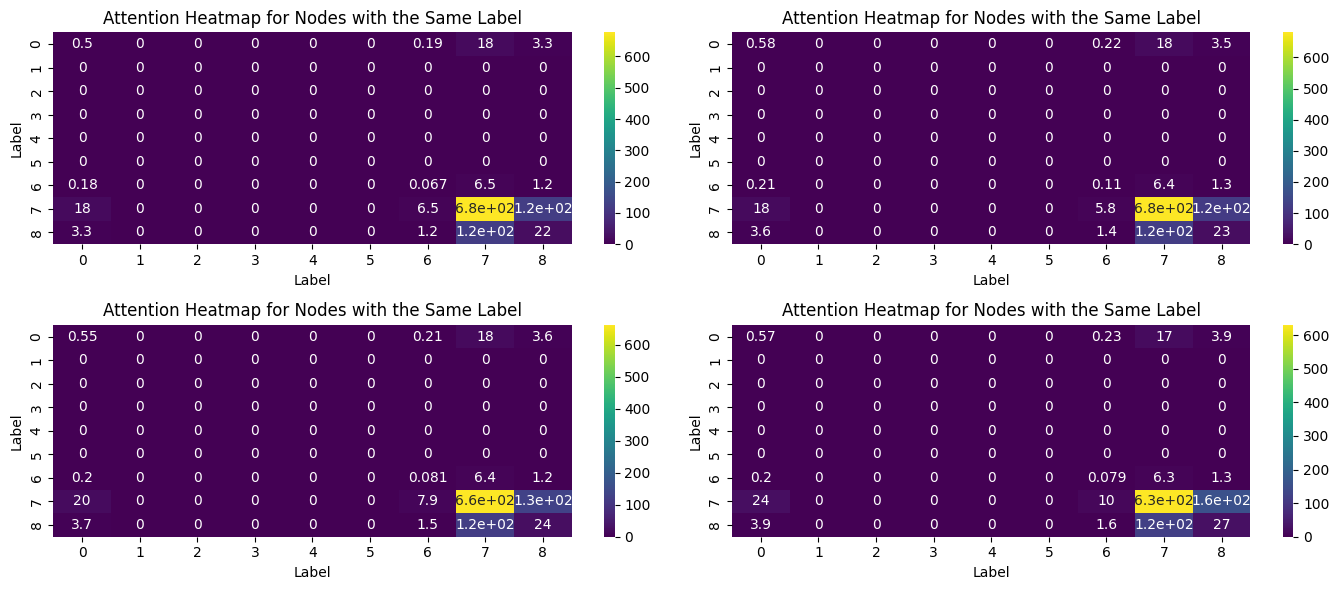

DataBatch(x=[3517, 960], edge_index=[2, 1906], y=[3517, 9], batch=[3517], ptr=[2])


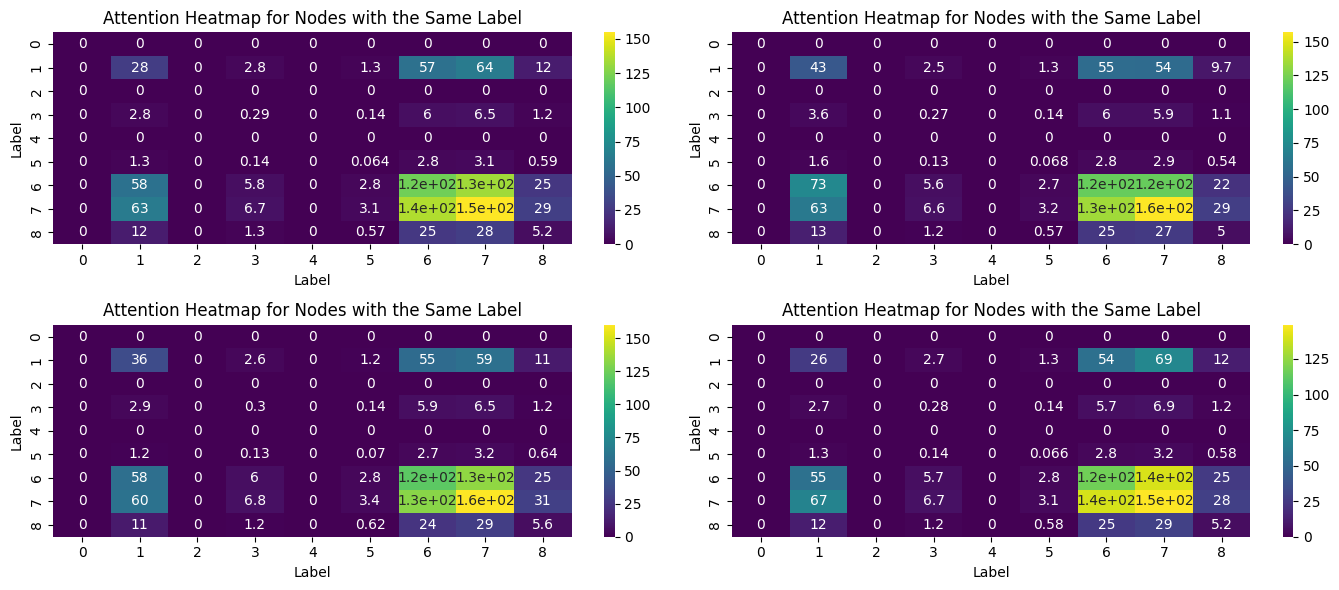

DataBatch(x=[457, 960], edge_index=[2, 38], y=[457, 9], batch=[457], ptr=[2])


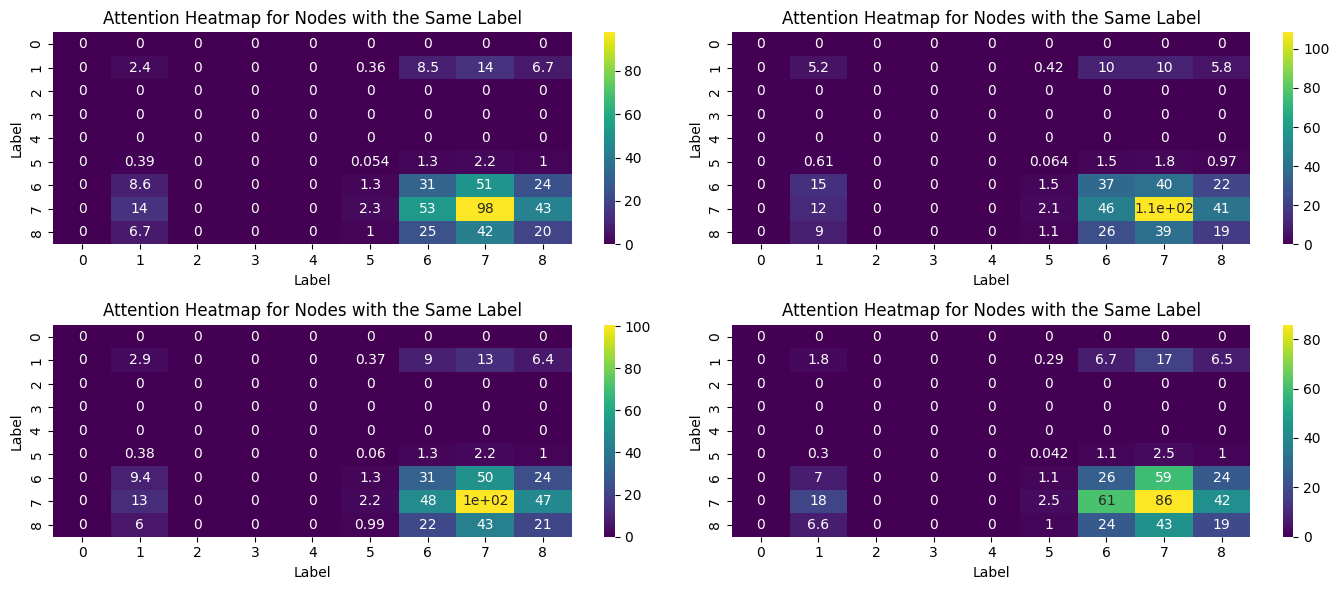

In [72]:
for batch in eval_loader:
    fig, axs = plt.subplots(2, 2, figsize=(14, 6))
    print(batch)
    transformer_in, src_padding_mask, index_nodes = eval(model, batch)
    attention_maps = extract_attention(model.transformer_encoder, transformer_in, src_padding_mask)
    for i, att_map in enumerate(attention_maps):
        label_attention_matrix = create_label_heatmap(batch, att_map.squeeze(0), index_nodes)

        ax = axs.flatten()[i]
        sns.heatmap(label_attention_matrix, ax=ax, cmap='viridis', annot=True)
        ax.set_xlabel('Label')
        ax.set_ylabel('Label')
        ax.set_title('Attention Heatmap for Nodes with the Same Label')

    plt.tight_layout()
    plt.show()

In [22]:
labels = pyg_data_val[0].y[1]
unique_labels = labels.unique()
print(labels)

tensor([0., 0., 0., 0., 0., 0., 0., 1., 0.])


In [33]:
a = attention_maps[0]
print((a.transpose(0, 1) == a).all())

tensor(False)
